This notebook integrates the machine learning failure-risk model with the maintenance optimization model. The objective is to use predicted reactor failure probabilities as input to a decision-support optimization model that recommends which reactors should receive preventive maintenance under limited technician capacity, downtime, and budget.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pred = pd.read_csv("../outputs/results/failure_risk_predictions.csv")

pred.head()

,timestamp,reactor_id,operating_regime,fault_type,failure_risk,efficiency_loss_pct,time_to_fault_min,predicted_failure_risk,predicted_failure_label
0,2024-03-13 00:00:00,B_R2,B,0,0,0.0,247.808042,0.049160,0
1,2024-03-13 00:00:00,A_R2,A,0,0,0.0,1108.964569,0.009079,0
2,2024-03-13 00:00:00,A_R1,A,0,0,0.0,0.000000,0.031384,0
3,2024-03-13 00:00:00,A_R3,A,0,0,0.0,789.800268,0.008600,0
4,2024-03-13 00:00:00,B_R1,B,0,0,0.0,239.625726,0.074982,0


In [3]:
pred.columns

Index(['timestamp', 'reactor_id', 'operating_regime', 'fault_type',
       'failure_risk', 'efficiency_loss_pct', 'time_to_fault_min',
       'predicted_failure_risk', 'predicted_failure_label'],
      dtype='object')

In [4]:
pred["valid_time_to_fault"] = pred["time_to_fault_min"].where(
    pred["time_to_fault_min"] > 0
)

reactor_decision_input = pred.groupby("reactor_id").agg(
    avg_predicted_failure_risk=("predicted_failure_risk", "mean"),
    max_predicted_failure_risk=("predicted_failure_risk", "max"),
    predicted_failure_count=("predicted_failure_label", "sum"),
    actual_failure_rate=("failure_risk", "mean"),
    avg_efficiency_loss=("efficiency_loss_pct", "mean"),
    min_time_to_fault=("valid_time_to_fault", "min"),
    avg_time_to_fault=("valid_time_to_fault", "mean")
).reset_index()

reactor_decision_input

,reactor_id,avg_predicted_failure_risk,max_predicted_failure_risk,predicted_failure_count,actual_failure_rate,avg_efficiency_loss,min_time_to_fault,avg_time_to_fault
0,A_R1,0.027764,0.149869,0,0.000000,0.000000,NaN,NaN
1,A_R2,0.065113,0.724842,1469,0.070139,1.052083,0.129741,588.307452
2,A_R3,0.037150,0.591525,772,0.042052,0.631173,1.000000,916.911186
3,B_R1,0.027000,0.799117,167,0.011883,0.178241,1.000000,267.470196
4,B_R2,0.021743,0.491916,21,0.013619,0.203799,1.000000,297.740539
5,B_R3,0.111759,0.983418,1363,0.055710,0.929208,0.029029,328.771599


In [5]:
#maintenance assumptions
reactor_decision_input["maintenance_hours"] = 3
reactor_decision_input["downtime_hours"] = 2
reactor_decision_input["maintenance_cost"] = 1000

available_technician_hours = 12
allowed_downtime_hours = 6
available_budget = 4000

In [6]:
#maintenance score
from sklearn.preprocessing import MinMaxScaler

reactor_decision_input["urgency_score"] = 1 / (
    reactor_decision_input["min_time_to_fault"] + 1
)

reactor_decision_input["urgency_score"] = (
    reactor_decision_input["urgency_score"].fillna(0)
)

score_cols = [
    "avg_predicted_failure_risk",
    "avg_efficiency_loss",
    "urgency_score"
]

scaler = MinMaxScaler()
scaled_scores = scaler.fit_transform(reactor_decision_input[score_cols])

reactor_decision_input["risk_score_norm"] = scaled_scores[:, 0]
reactor_decision_input["efficiency_loss_norm"] = scaled_scores[:, 1]
reactor_decision_input["urgency_score_norm"] = scaled_scores[:, 2]

reactor_decision_input["maintenance_benefit"] = (
    0.5 * reactor_decision_input["risk_score_norm"]
    + 0.3 * reactor_decision_input["efficiency_loss_norm"]
    + 0.2 * reactor_decision_input["urgency_score_norm"]
)

reactor_decision_input = reactor_decision_input.sort_values(
    "maintenance_benefit",
    ascending=False
)

reactor_decision_input[
    [
        "reactor_id",
        "avg_predicted_failure_risk",
        "avg_efficiency_loss",
        "min_time_to_fault",
        "maintenance_benefit"
    ]
]

,reactor_id,avg_predicted_failure_risk,avg_efficiency_loss,min_time_to_fault,maintenance_benefit
5,B_R3,0.111759,0.929208,0.029029,0.964962
1,A_R2,0.065113,1.052083,0.129741,0.723071
2,A_R3,0.037150,0.631173,1.000000,0.368460
3,B_R1,0.027000,0.178241,1.000000,0.182925
4,B_R2,0.021743,0.203799,1.000000,0.161016
0,A_R1,0.027764,0.000000,NaN,0.033443


The maintenance benefit score combines three decision factors: predicted failure risk, expected efficiency loss, and urgency. The weights are set to 50% risk, 30% efficiency loss, and 20% urgency. These weights can be adjusted depending on business priorities.

In [ ]:
from pulp import (
    LpProblem,
    LpVariable,
    LpMaximize,
    lpSum,
    LpBinary,
    LpStatus,
    value
)

reactors = reactor_decision_input["reactor_id"].tolist()

model = LpProblem(
    "Integrated_Predictive_Maintenance_Optimization",
    LpMaximize
)
#decision variable
x = {
    r: LpVariable(f"maintain_{r}", cat=LpBinary)
    for r in reactors
}
#objective
model += lpSum(
    reactor_decision_input.loc[
        reactor_decision_input["reactor_id"] == r,
        "maintenance_benefit"
    ].values[0] * x[r]
    for r in reactors
)
#constraints
model += lpSum(
    reactor_decision_input.loc[
        reactor_decision_input["reactor_id"] == r,
        "maintenance_hours"
    ].values[0] * x[r]
    for r in reactors
) <= available_technician_hours

model += lpSum(
    reactor_decision_input.loc[
        reactor_decision_input["reactor_id"] == r,
        "downtime_hours"
    ].values[0] * x[r]
    for r in reactors
) <= allowed_downtime_hours

model += lpSum(
    reactor_decision_input.loc[
        reactor_decision_input["reactor_id"] == r,
        "maintenance_cost"
    ].values[0] * x[r]
    for r in reactors
) <= available_budget

#solve
model.solve()

print("Status:", LpStatus[model.status])
print("Objective value:", value(model.objective))

Status: Optimal
Objective value: 2.056493527480121


In [8]:
#final maintenance recommendations
final_recommendations = reactor_decision_input.copy()

final_recommendations["selected_for_maintenance"] = final_recommendations["reactor_id"].apply(
    lambda r: int(x[r].value())
)

final_recommendations = final_recommendations.sort_values(
    ["selected_for_maintenance", "maintenance_benefit"],
    ascending=[False, False]
)

final_recommendations[
    [
        "reactor_id",
        "avg_predicted_failure_risk",
        "avg_efficiency_loss",
        "min_time_to_fault",
        "maintenance_benefit",
        "maintenance_hours",
        "downtime_hours",
        "maintenance_cost",
        "selected_for_maintenance"
    ]
]

,reactor_id,avg_predicted_failure_risk,avg_efficiency_loss,min_time_to_fault,maintenance_benefit,maintenance_hours,downtime_hours,maintenance_cost,selected_for_maintenance
5,B_R3,0.111759,0.929208,0.029029,0.964962,3,2,1000,1
1,A_R2,0.065113,1.052083,0.129741,0.723071,3,2,1000,1
2,A_R3,0.037150,0.631173,1.000000,0.368460,3,2,1000,1
3,B_R1,0.027000,0.178241,1.000000,0.182925,3,2,1000,0
4,B_R2,0.021743,0.203799,1.000000,0.161016,3,2,1000,0
0,A_R1,0.027764,0.000000,NaN,0.033443,3,2,1000,0


In [9]:
final_recommendations.to_csv(
    "../outputs/results/final_integrated_maintenance_recommendations.csv",
    index=False
)

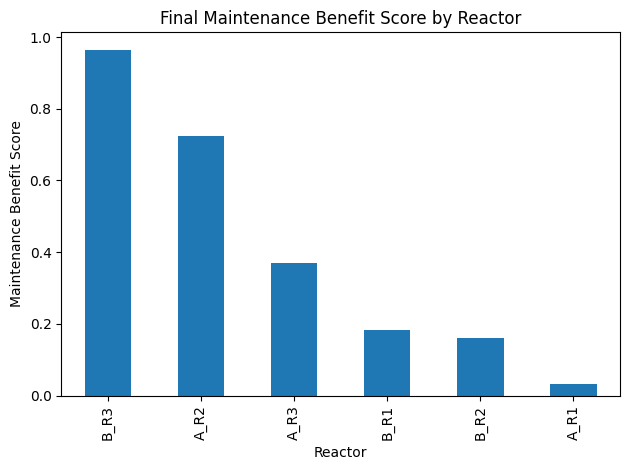

In [10]:
#ploting final recommendations
final_recommendations.sort_values("maintenance_benefit", ascending=False).plot(
    x="reactor_id",
    y="maintenance_benefit",
    kind="bar",
    legend=False
)

plt.title("Final Maintenance Benefit Score by Reactor")
plt.xlabel("Reactor")
plt.ylabel("Maintenance Benefit Score")
plt.tight_layout()
plt.savefig("../outputs/figures/final_maintenance_benefit_score.png")
plt.show()

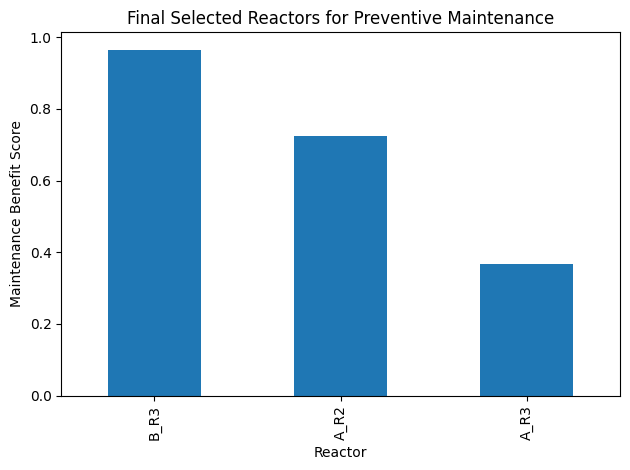

In [11]:
#selected reactors
selected = final_recommendations[
    final_recommendations["selected_for_maintenance"] == 1
]

selected.plot(
    x="reactor_id",
    y="maintenance_benefit",
    kind="bar",
    legend=False
)

plt.title("Final Selected Reactors for Preventive Maintenance")
plt.xlabel("Reactor")
plt.ylabel("Maintenance Benefit Score")
plt.tight_layout()
plt.savefig("../outputs/figures/selected_reactors_final.png")
plt.show()

The final output is not only a prediction of which reactors are risky, but a maintenance recommendation showing which reactors should be prioritized when resources are limited.